In [3]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pynbody
import pynbody.plot.sph as sph
from IPython.display import clear_output, display
import h5py

# fourier
from scipy.signal import stft as short_time_fft
from scipy.ndimage import gaussian_filter1d
from scipy.signal import ShortTimeFFT, find_peaks, get_window
from scipy.signal import windows

# dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

SMALLSIZE = 12
NORMALSIZE = 12
LARGESIZE = 12

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

isob_dir = "../data/IsoB_dt10_all"
snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]
iord_dir  = "../data/fil_iords.csv"

HDF5DIR = "../data/IsoB_faceon.h5"
h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]


In [ ]:
for i, snap in enumerate(snap_names):
    sim = pynbody.load(f"{isob_dir}/{snap}")
    sim.physical_units()
    pynbody.analysis.angmom.faceon(sim)
    df = pd.DataFrame(dict(
        iord = sim.s['iord'],
        x = sim.s['x'],
        y = sim.s['y'],
        z = sim.s['z'],
        mass = sim.s['mass']
    ))
    text = snap.split(".")
    df.to_csv(f"../data/IsoB_dt10_stars/{text[0]}.0{text[1]}.csv")
    print(i)

In [ ]:
sim = pynbody.load(f"{isob_dir}/{"GLX.01000"}")
final_iords = sim.s['iord']
fx = sim.s['x']
fy = sim.s['y']
fz = sim.s['z']
fr = np.sqrt(fx**2 + fy**2)

mask = (fr < 10) & (fz < 5) & (fz > -5)

np.savetxt("../data/fil_iords.csv", final_iords[mask], delimiter=",")

In [4]:
def extract_stellar_data1(snap, iords): # for glx00610 and earlier AND glx0960 and later
    snap.physical_units()
    pynbody.analysis.angmom.faceon(snap)

    r = np.sqrt(snap.s['x']**2 + snap.s['y']**2)
    az = np.atan2(snap.s['y'], snap.s['x'])

    data = pd.DataFrame(dict(
        iord = np.array(snap.s['iord']),
        x = np.array(snap.s['x']),
        y = np.array(snap.s['y']),
        z = np.array(snap.s['z']),
        mass = np.array(snap.s['mass']),
        r = np.array(r),
        az = np.array(az)
    ))
    data = data[data['iord'].isin(iords)]
    return data

def extract_stellar_data2(snap, iords): # for glx00620 to glx0950
    snap.physical_units()
    pynbody.analysis.angmom.faceon(snap)

    r = np.sqrt(snap.s['x']**2 + snap.s['y']**2)
    az = np.atan2(snap.s['y'], snap.s['x'])

    data = pd.DataFrame(dict(
        iord = np.array(snap.s['iord.txt']),
        x = np.array(snap.s['x']),
        y = np.array(snap.s['y']),
        z = np.array(snap.s['z']),
        mass = np.array(snap.s['mass']),
        r = np.array(r),
        az = np.array(az)
    ))
    data = data[data['iord'].isin(iords)]
    return data


def save_to_hdf5(hdf5_dir, df, key):
    df.to_hdf(hdf5_dir, key=key, mode='a', complib='blosc', complevel=5)

In [5]:
iords = np.loadtxt(iord_dir)

for i, snap in enumerate(snap_names):

    sim = pynbody.load(f"{isob_dir}/{snap}")
    

    if i < 61:
        data = extract_stellar_data1(sim, iords)
    elif i < 95:
        data = extract_stellar_data2(sim, iords)
    else:
        data = extract_stellar_data1(sim, iords)
        
    print(i)
    #save_to_hdf5(HDF5DIR, data, f"GLX{10*(i+1):04.0f}")
    save_to_hdf5("../data/fIsoB_faceon.h5", data, f"GLX{10*(i+1):04.0f}")


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


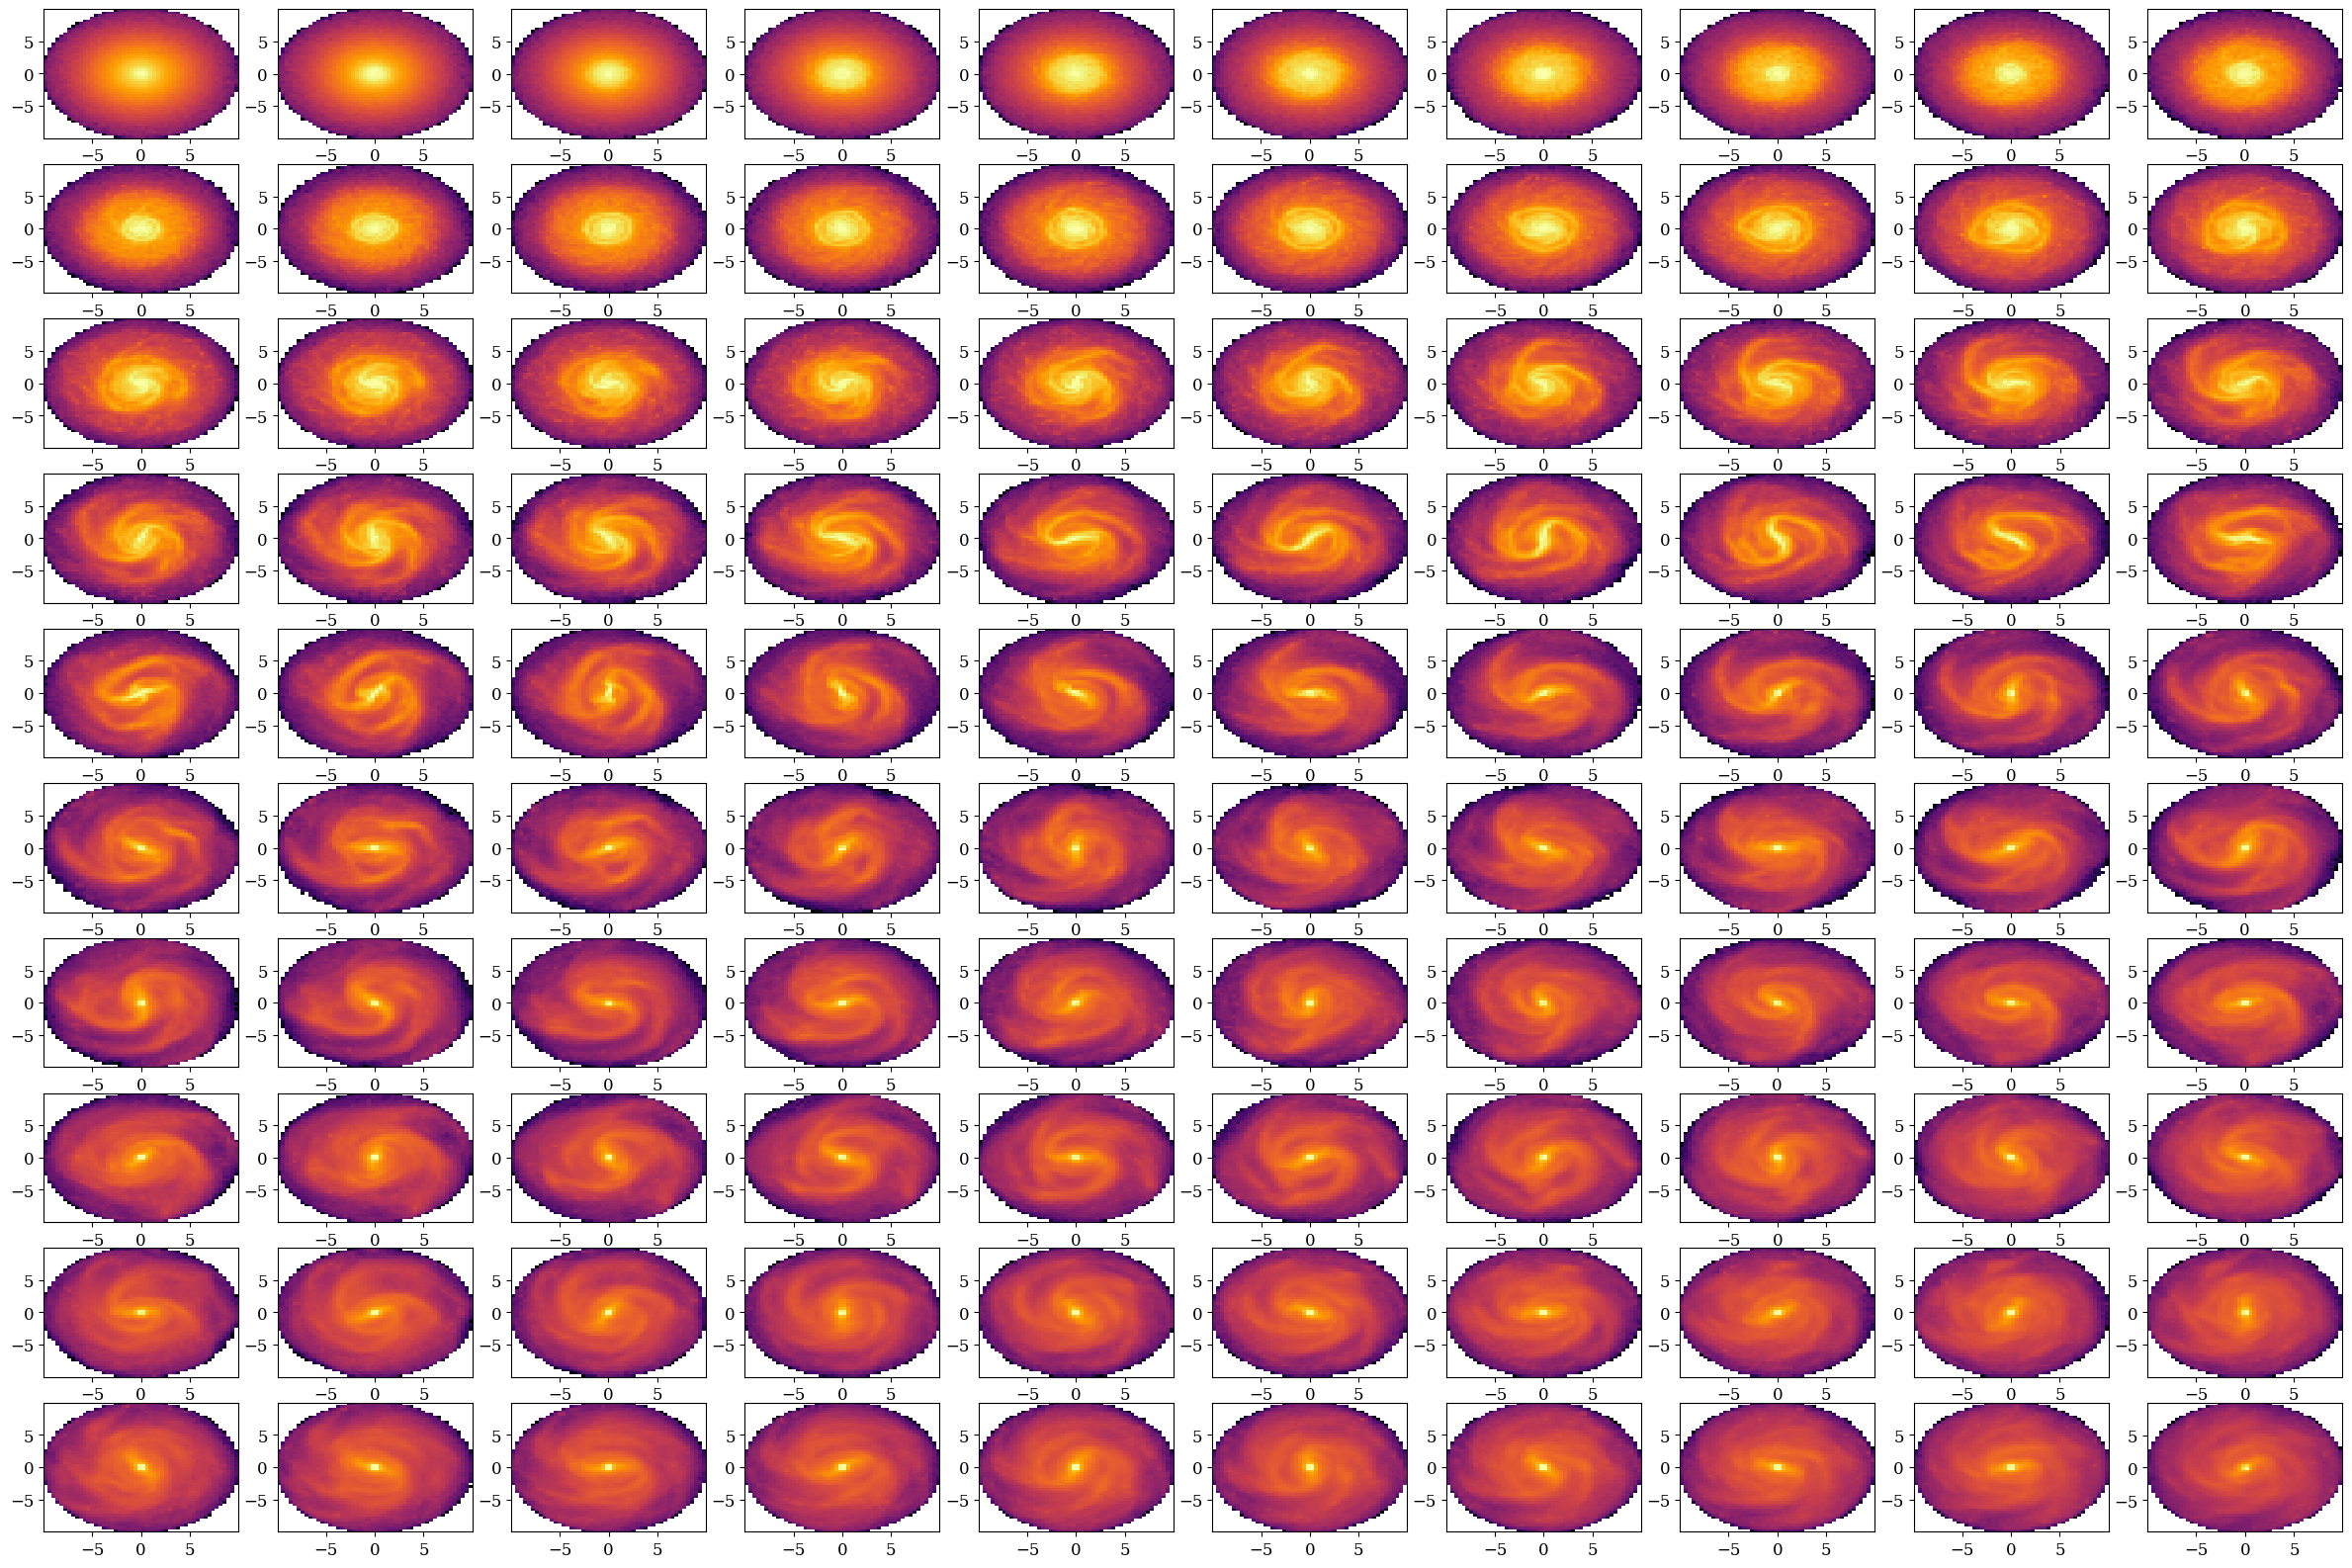

In [9]:
h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]

ncols = 10
nrows = 10 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(3*ncols, 2*ncols)
axes = axes.ravel()

for i, key in enumerate(h5keys):
    # fig, ax = plt.subplots()
    # fig.set_size_inches(3,2)
    ax = axes[i]
    data = pd.read_hdf("../data/fIsoB_faceon.h5", key=key).copy()
    data = data[data['r'] < 10]

    ax.hist2d(data['x'], data['y'], bins=50, norm='log', cmap='inferno')
    print(i)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


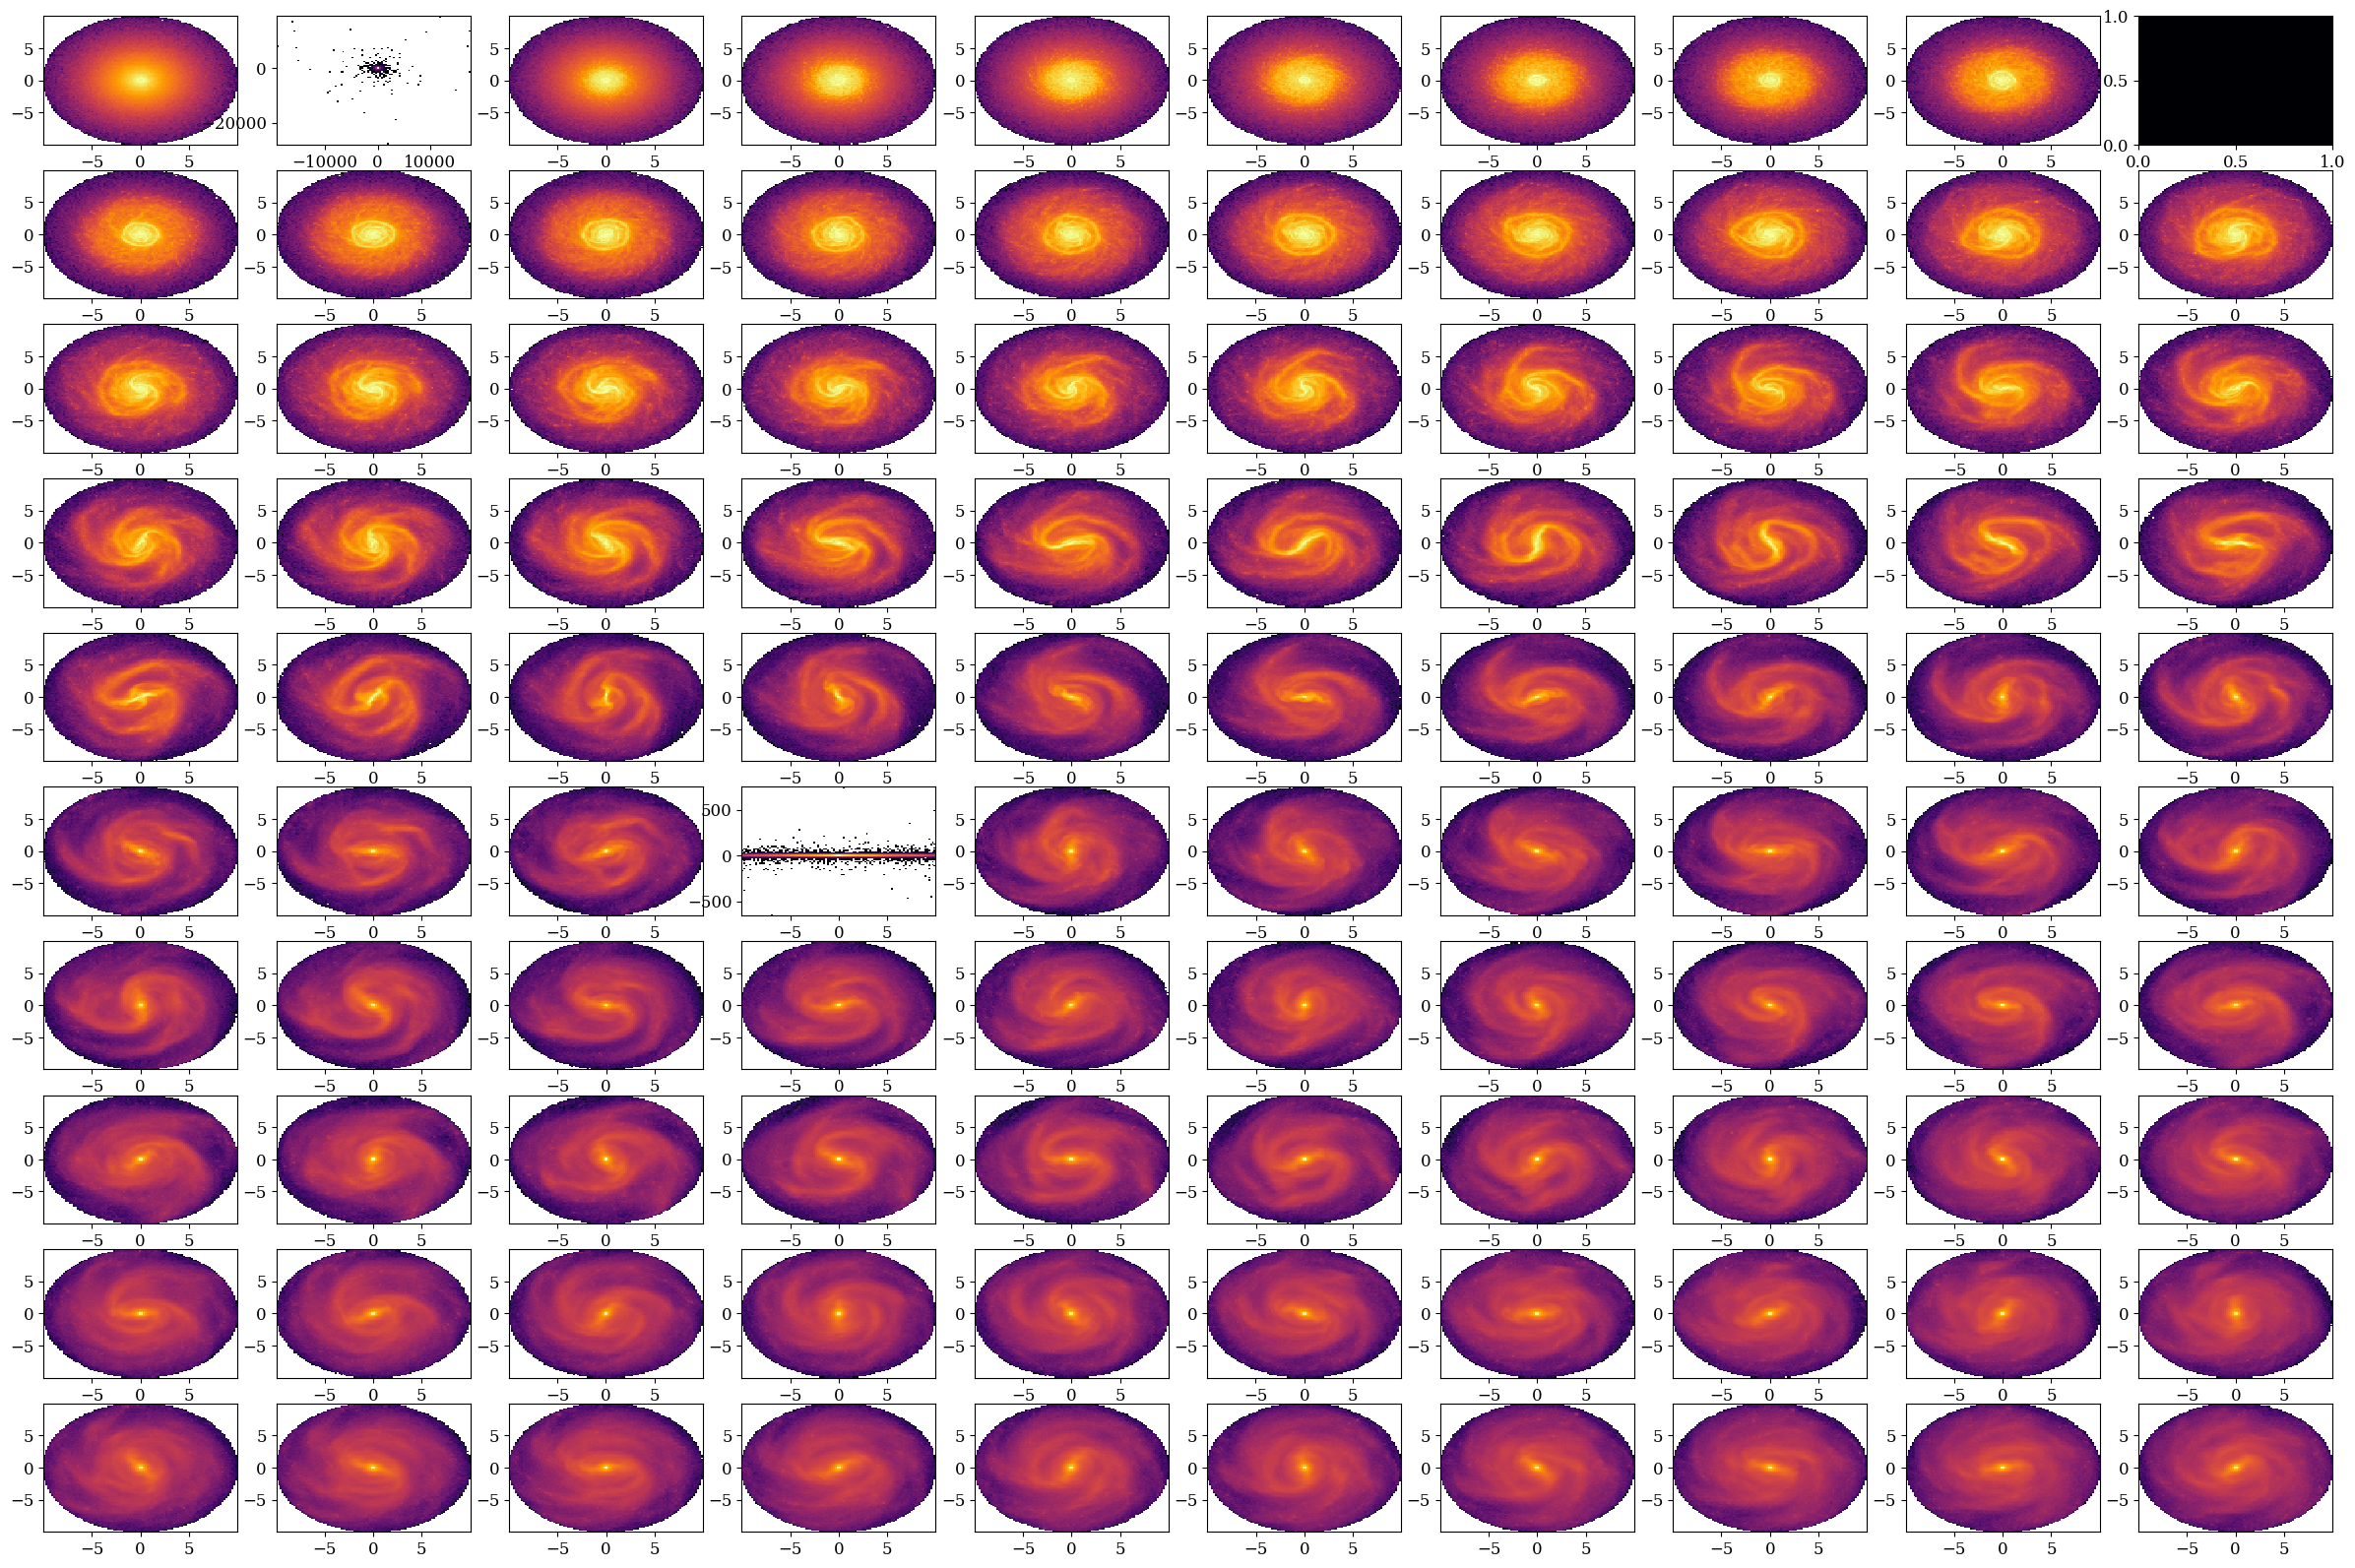

In [7]:
h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]

ncols = 10
nrows = 10 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(3*ncols, 2*ncols)
axes = axes.ravel()

for i, key in enumerate(h5keys):
    # fig, ax = plt.subplots()
    # fig.set_size_inches(3,2)
    ax = axes[i]
    data = pd.read_hdf(HDF5DIR, key=key).copy()
    data['r'] = np.sqrt(data['x']**2 + data['y']**2)
    sub = data[data['r'] < 10].copy()
    ax.hist2d(sub['x'], sub['y'], bins=100, norm='log', cmap='inferno')
    print(i)


In [16]:
# attempting to find the stars born between 200 and 250

df250 = pd.read_hdf("../data/fIsoB_faceon.h5", key="GLX0250")
df200 = pd.read_hdf("../data/fIsoB_faceon.h5", key="GLX0200")

iord250 = set(df250['iord'])
iord200 = set(df200['iord'])

pop_iords = list(iord250 - iord200)
np.savetxt("../data/pop_iords.csv", pop_iords, delimiter=",")

In [24]:
h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]
target_iords = np.loadtxt("../data/pop_iords.csv")

data_cube = np.zeros((3, 100, len(target_iords)))
print(data_cube.shape)


for i, key in enumerate(h5keys):
    df = pd.read_hdf(f"../data/fIsoB_faceon.h5", key=key)
    df_sort = df.set_index('iord').reindex(target_iords)

    data_cube[0, i, :] = df_sort['x'].values
    data_cube[1, i, :] = df_sort['y'].values
    data_cube[2, i, :] = df_sort['z'].values

    print(i)
    
    

(3, 100, 189513)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [33]:
rdc = data_cube[:, 25:, :]
print(rdc)
print(np.isnan(rdc).any())

[[[ 6.31060225e+00  7.84315468e+00  7.13923115e-02 ... -4.41218931e+00
   -1.46836612e-01 -6.06472504e-01]
  [ 5.58599640e+00  8.50437692e+00 -6.21785763e-01 ... -5.47870261e+00
    6.47739926e-01  5.78768057e-01]
  [ 4.30029111e+00  8.75376942e+00  2.18203085e-01 ... -5.85370164e+00
    1.68153660e-01  8.93984920e-01]
  ...
  [ 4.37816200e-01 -7.01933327e+00 -3.22311676e-02 ... -1.26620610e+00
    2.41719362e-01  2.05418418e-02]
  [-1.57551104e+00 -5.57921569e+00 -4.05273040e-02 ... -2.81283402e+00
   -1.09527765e-01  1.02598066e-02]
  [-3.47159893e+00 -3.87671532e+00 -6.27432885e-02 ... -4.16083120e+00
   -1.21675814e-01 -3.40782132e-01]]

 [[ 7.99462504e-01 -4.00478253e+00  4.52138667e-01 ...  3.75409173e+00
   -1.09681638e+00 -8.43555698e-01]
  [ 2.77918325e+00 -2.34261004e+00  1.49536206e-01 ...  1.95378864e+00
   -6.42236038e-01 -9.99926948e-01]
  [ 4.47293777e+00 -5.68169032e-01 -1.27356175e-01 ... -6.87074233e-02
    5.43598030e-01  3.10626393e-02]
  ...
  [ 7.78353215e+00 -5.6

In [44]:
import cupy as cpy
def stft_gpu(data, fs, nperseg=16, noverlap=14):
    n_times, n_stars = data.shape
    step = nperseg-noverlap

    win = cpy.hanning(nperseg)[:, None]

    shape = ((n_times - nperseg) // step + 1, nperseg, n_stars)
    strides = (data.strides[0] * step, data.strides[0], data.strides[1])
    segments = cpy.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)

    stft_result = cpy.fft.rfft(segments * win, axis=1)

    freqs = cpy.fft.rfftfreq(nperseg, 1/fs)
    times = cpy.arange(shape[0]) * (step / fs) + (nperseg / (2 * fs))

    return freqs, times, stft_result

x_gpu = cpy.asarray(rdc[1, :, :])

freqs, times, Zxx = stft_gpu(x_gpu, 1/10)
Zxx_mag = cpy.abs(Zxx)**2

In [45]:
print(Zxx_mag.shape)

(30, 9, 189513)


C:\Users\Misha\AppData\Local\Temp\ipykernel_38740\2162660335.py:5: UserWarning: shading value 'imshow' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  plt.pcolormesh((cpy.asnumpy(times) + 250), cpy.asnumpy(freqs), ssp.T, shading='imshow', cmap='viridis', norm='log', vmin=1e-1)


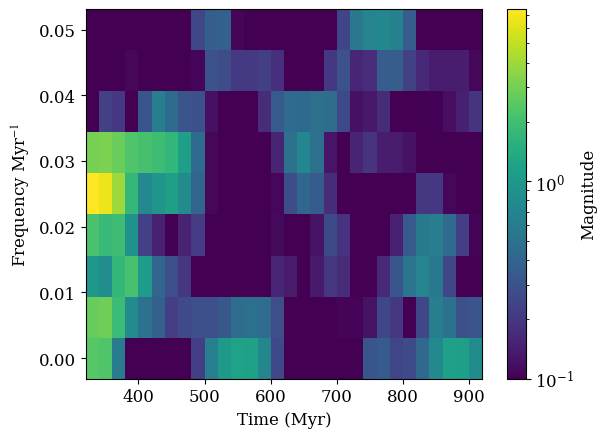

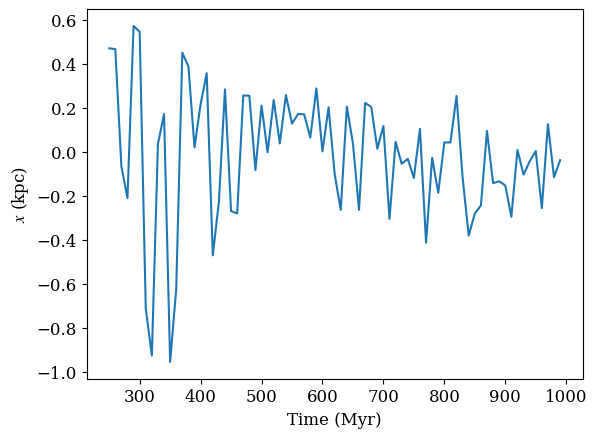

In [79]:

id = 2700
# 20550
ssp = cpy.asnumpy(Zxx_mag[:, :, id])

plt.pcolormesh((cpy.asnumpy(times) + 250), cpy.asnumpy(freqs), ssp.T, shading='imshow', cmap='viridis', norm='log', vmin=1e-1)
cb= plt.colorbar()
cb.set_label("Magnitude")
plt.xlabel('Time (Myr)')
plt.ylabel("Frequency Myr$^{-1}$")
plt.show()
plt.clf()

x_vals = rdc[1, :, id]
t_ax = np.arange(len(x_vals))*10 + 250
plt.plot(t_ax, x_vals)
plt.xlabel("Time (Myr)")
plt.ylabel("$x$ (kpc)")
plt.show()

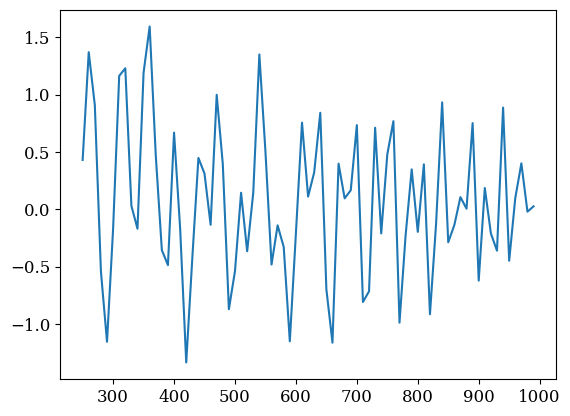

In [27]:
with h5py.File("../data/data_cube.h5", 'w') as f:
    dset = f.create_dataset('coords_data', data=data_cube, compression='gzip', chunks=True)
    dset.attrs['description'] = "Data cube shape (3, 100, 189513) for (Axis, Timestep, Iord)"

In [30]:
with h5py.File('../data/data_cube.h5', 'r') as f:
    data_c = f['coords_data'][:]

print(data_c.shape)

(3, 100, 189513)


In [52]:
sample = np.array([[1006950591, 1007046373, 1006454116, 1006790661, 1006352091, 1006856162,
 1006313199, 1006396387, 1006216061, 1007161072]])

datassss = []

for i, key in enumerate(h5keys):
    data = pd.read_hdf("../data/IsoB.h5", key=key)
    data = data[data['iord'].isin(sample)]
    datassss.append(np.array(data[['x', 'y', 'z']]))

datassss = np.dstack(datassss)
